In [14]:
#liabraries to be imported 
!pip install scikit-learn pandas numpy matplotlib seaborn

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import LabelEncoder
%matplotlib inline

In [16]:
#Create House Price Dataset
# We create this ourselves — no upload needed! - price depends on area,bedroom,bathroom,age.
np.random.seed(42)
n = 200

df = pd.DataFrame({
    'Area_sqft'    : np.random.randint(500, 4000, n),
    'Bedrooms'     : np.random.randint(1, 6, n),
    'Bathrooms'    : np.random.randint(1, 4, n),
    'Age_of_House' : np.random.randint(1, 50, n),
    'Garage'       : np.random.choice(['Yes', 'No'], n),
    'Location'     : np.random.choice(['Urban', 'Suburb', 'Rural'], n),
})

# Price formula — bigger area = higher price (realistic)
df['Price'] = (
    df['Area_sqft'] * 150 +
    df['Bedrooms']  * 10000 +
    df['Bathrooms'] * 8000 -
    df['Age_of_House'] * 500 +
    (df['Garage'] == 'Yes').astype(int) * 15000 +
    np.random.randint(-20000, 20000, n)  # random noise
)

print("Dataset Created!")
print("Shape:", df.shape)
display(df.head(10))

Dataset Created!
Shape: (200, 7)


,Area_sqft,Bedrooms,Bathrooms,Age_of_House,Garage,Location,Price
0,3674,4,2,23,Yes,Urban,596379
1,1360,4,3,16,No,Rural,252298
2,1794,3,3,39,No,Suburb,297753
3,1630,2,2,45,Yes,Urban,263789
4,1595,4,3,42,Yes,Urban,290249
5,3592,1,1,39,Yes,Suburb,533114
6,2138,1,2,14,No,Suburb,330241
7,2669,1,3,31,Yes,Suburb,438788
8,966,1,2,5,Yes,Rural,165843
9,1738,3,1,35,Yes,Rural,286657


In [17]:
#EDA 
print("Shape:", df.shape)
print("\nColumn Info:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Stats:")
display(df.describe())

Shape: (200, 7)

Column Info:
Area_sqft        int32
Bedrooms         int32
Bathrooms        int32
Age_of_House     int32
Garage          object
Location        object
Price            int32
dtype: object

Missing Values:
Area_sqft       0
Bedrooms        0
Bathrooms       0
Age_of_House    0
Garage          0
Location        0
Price           0
dtype: int64

Basic Stats:


,Area_sqft,Bedrooms,Bathrooms,Age_of_House,Price
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,2333.775000,2.780000,1.895000,24.580000,389107.640000
std,992.421831,1.393308,0.816891,14.456088,151671.964853
min,521.000000,1.000000,1.000000,1.000000,87166.000000
25%,1519.000000,1.000000,1.000000,12.000000,262589.000000
50%,2372.000000,3.000000,2.000000,25.000000,400183.000000
75%,3229.500000,4.000000,3.000000,37.000000,524780.750000
max,3999.000000,5.000000,3.000000,49.000000,660861.000000


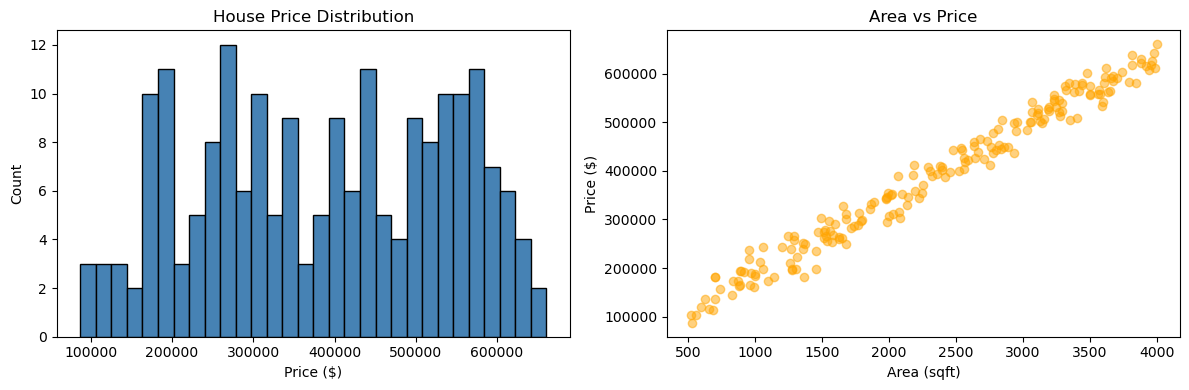

In [18]:
#Visualize price distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Price distribution
axes[0].hist(df['Price'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title("House Price Distribution")
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("Count")

# Area vs Price
axes[1].scatter(df['Area_sqft'], df['Price'], color='orange', alpha=0.5)
axes[1].set_title("Area vs Price")
axes[1].set_xlabel("Area (sqft)")
axes[1].set_ylabel("Price ($)")

plt.tight_layout()
plt.show()

In [19]:
#preprocessing 
# ML models only understand NUMBERS — not text like "Yes/No" or "Urban"
# So we convert text → numbers using LabelEncoder

le = LabelEncoder()

df['Garage_enc']   = le.fit_transform(df['Garage'])    # Yes=1, No=0
df['Location_enc'] = le.fit_transform(df['Location'])  # Urban=2, Suburb=1, Rural=0

print("Encoding Done!")
print("\nGarage unique values:", df['Garage'].unique())
print("Garage encoded     :", df['Garage_enc'].unique())
print("\nLocation unique    :", df['Location'].unique())
print("Location encoded   :", df['Location_enc'].unique())

Encoding Done!

Garage unique values: ['Yes' 'No']
Garage encoded     : [1 0]

Location unique    : ['Urban' 'Rural' 'Suburb']
Location encoded   : [2 0 1]


In [20]:
#Feature selection
# X = INPUT features (what we give the model)
# y = OUTPUT / target (what we want to predict)

X = df[['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_of_House', 'Garage_enc', 'Location_enc']]
y = df['Price']

print("Features Selected!")
print("\nInput Features (X):")
display(X.head())
print("\nTarget (y) - Price:")
print(y.head())

Features Selected!

Input Features (X):


,Area_sqft,Bedrooms,Bathrooms,Age_of_House,Garage_enc,Location_enc
0,3674,4,2,23,1,2
1,1360,4,3,16,0,0
2,1794,3,3,39,0,1
3,1630,2,2,45,1,2
4,1595,4,3,42,1,2



Target (y) - Price:
0    596379
1    252298
2    297753
3    263789
4    290249
Name: Price, dtype: int32


In [21]:
#train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% for testing
    random_state=42    # same split every time
)

print("Split Done!")
print("Training rows  :", len(X_train))  # 160 rows
print("Testing rows   :", len(X_test))   # 40 rows

Split Done!
Training rows  : 160
Testing rows   : 40


In [22]:
#train the model 
model = LinearRegression()       # Step 1 — Create model
model.fit(X_train, y_train)      # Step 2 — Train on training data

print("Model Trained!")
print("\nModel Coefficients (how much each feature affects price):")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature:20s} : {coef:.2f}")
print(f"\n  Intercept : {model.intercept_:.2f}")

Model Trained!

Model Coefficients (how much each feature affects price):
  Area_sqft            : 149.91
  Bedrooms             : 10226.05
  Bathrooms            : 8363.23
  Age_of_House         : -524.91
  Garage_enc           : 12908.38
  Location_enc         : -403.60

  Intercept : 1477.16


In [23]:
#predict
y_pred = model.predict(X_test)   # Predict on test data

print("Predictions Done!")
print("\nActual vs Predicted (first 10):")
comparison = pd.DataFrame({
    'Actual Price'   : y_test.values[:10],
    'Predicted Price': y_pred[:10].round(0)
})
display(comparison)

Predictions Done!

Actual vs Predicted (first 10):


,Actual Price,Predicted Price
0,486308,469841.0
1,563945,548849.0
2,630303,639697.0
3,188571,192000.0
4,191021,181537.0
5,103119,116063.0
6,335696,326952.0
7,540367,523519.0
8,119935,124061.0
9,575730,557692.0


In [24]:
#evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=" * 40)
print("       MODEL EVALUATION REPORT")
print("=" * 40)
print(f"  RMSE : ${rmse:,.0f}")
print(f"  R²   : {r2:.4f}  ({r2*100:.1f}%)")
print("=" * 40)

if r2 >= 0.9:
    print(" Excellent Model!")
elif r2 >= 0.75:
    print("Good Model!")
else:
    print("Model needs improvement")

       MODEL EVALUATION REPORT
  RMSE : $10,476
  R²   : 0.9958  (99.6%)
 Excellent Model!


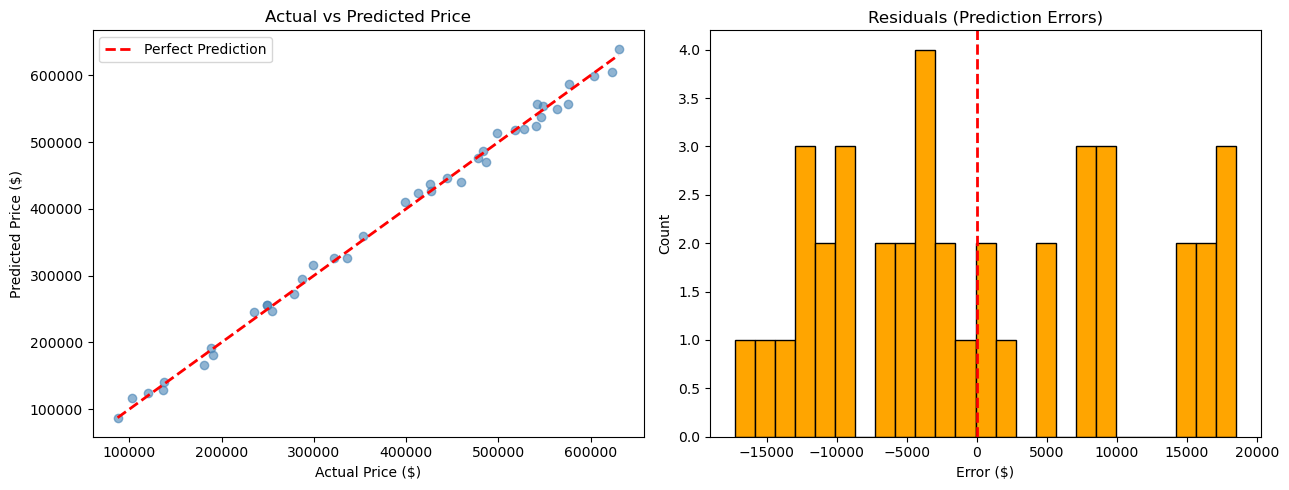

In [25]:
#visualize actual vs predicted
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1 — Actual vs Predicted scatter
axes[0].scatter(y_test, y_pred, color='steelblue', alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='red', linewidth=2, linestyle='--', label='Perfect Prediction')
axes[0].set_title("Actual vs Predicted Price")
axes[0].set_xlabel("Actual Price ($)")
axes[0].set_ylabel("Predicted Price ($)")
axes[0].legend()

# Plot 2 — Residuals (errors)
residuals = y_test.values - y_pred
axes[1].hist(residuals, bins=25, color='orange', edgecolor='black')
axes[1].axvline(x=0, color='red', linewidth=2, linestyle='--')
axes[1].set_title("Residuals (Prediction Errors)")
axes[1].set_xlabel("Error ($)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [26]:
#predict our own house
# Try predicting price for a custom house!
my_house = pd.DataFrame({
    'Area_sqft'    : [2000],
    'Bedrooms'     : [3],
    'Bathrooms'    : [2],
    'Age_of_House' : [10],
    'Garage_enc'   : [1],    # 1 = Yes
    'Location_enc' : [2]     # 2 = Urban
})

predicted_price = model.predict(my_house)[0]
print("Your House Details:")
print("   Area: 2000 sqft | 3 Bed | 2 Bath | 10 yrs old | Garage: Yes | Urban")
print(f"\nPredicted Price: ${predicted_price:,.0f}")

Your House Details:
   Area: 2000 sqft | 3 Bed | 2 Bath | 10 yrs old | Garage: Yes | Urban

Predicted Price: $355,551
